In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [3]:
# 读取四张表的数据
#读取了订单和产品id的关联，csv比较大
prior = pd.read_csv("./data/instacart/order_products__prior.csv")
#产品id，与过道的对应
products = pd.read_csv("./data/instacart/products.csv")
#订单id和用户id的对应，csv比较大
orders = pd.read_csv("./data/instacart/orders.csv")
#超市的过道，过道放的产品的品类
aisles = pd.read_csv("./data/instacart/aisles.csv")

In [4]:
# 合并四张表到一张表中，
#用户买了哪些订单，订单里面有哪些产品，产品对应的过道，过道对应的产品类别
_mg = pd.merge(prior, products, on=['product_id', 'product_id'])
_mg = pd.merge(_mg, orders, on=['order_id', 'order_id'])
mt = pd.merge(_mg, aisles, on=['aisle_id', 'aisle_id'])

In [5]:
mt.isnull().sum()/mt.shape[0]  #数据缺失率，没有缺失值

order_id                  0.00000
product_id                0.00000
add_to_cart_order         0.00000
reordered                 0.00000
product_name              0.00000
aisle_id                  0.00000
department_id             0.00000
user_id                   0.00000
eval_set                  0.00000
order_number              0.00000
order_dow                 0.00000
order_hour_of_day         0.00000
days_since_prior_order    0.06407
aisle                     0.00000
dtype: float64

In [6]:
# 交叉表（特殊的分组工具），如果在这一步内存不够了，重启一下jupyter，还是不行，筛选一部分用户的数据，进行聚类
# pd.crosstab() 是 pandas 中专门用于生成交叉表（列联表） 的核心方法，简单来说，它能帮你快速统计两个或多个分类变量之间的频数分布，是数据分析中探索分类变量关系的常用工具。
cross = pd.crosstab(mt['user_id'], mt['aisle'])

In [7]:
cross.head()

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,3,0,0,0,0,2,0,0,0,...,3,1,1,0,0,0,0,2,0,42
3,0,0,0,0,0,0,0,0,0,0,...,4,1,0,0,0,0,0,2,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
5,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3


In [10]:
pca = PCA(n_components=0.9)
data = pca.fit_transform(cross)

In [11]:
# 减少样本数量，方便画图
x = data[:500]
x[:10]

array([[-2.42156587e+01,  2.42942720e+00, -2.46636975e+00,
        -1.45686388e-01,  2.69042476e-01, -1.43293209e+00,
         2.14067666e+00, -2.73803122e+00, -2.71431623e+00,
        -1.74313529e+00, -1.13632718e+00,  6.73601069e-01,
        -1.65070735e+00,  2.83802486e+00, -5.89384489e+00,
         7.84312891e+00, -4.84010146e+00, -3.22598697e+00,
        -4.58007571e+00,  7.77403349e-01, -3.69912893e+00,
         1.90721439e+00,  2.99538594e+00,  7.72922878e-01,
         6.86800336e-01,  1.69439402e+00, -2.34323022e+00],
       [ 6.46320806e+00,  3.67511165e+01,  8.38255336e+00,
         1.50975303e+01, -6.92093785e+00, -9.78375183e-01,
         6.01156653e+00,  3.78772465e+00, -8.18074883e+00,
        -9.04086141e+00, -5.61352902e+00, -1.11325323e+00,
         2.96702911e+00, -4.73123497e+00,  9.11472283e+00,
         2.14709471e-01,  1.29694031e+00, -7.37605505e-01,
        -7.37401979e-01,  7.40042249e-01, -9.13382968e-02,
         5.15128465e+00, -4.58481528e+00, -3.23789431e+

In [19]:
# 生成kmeans估计器
# 分成四个类别
km = KMeans(n_clusters=3)
km.fit(x)

KMeans(n_clusters=3)

In [20]:
# 开始预测
predict = km.predict(x)
print(predict)

[1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 2 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1
 0 1 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 1
 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 2 1 0 0 1 1 0 1 1
 1 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 2 1 0 1 1 0 2 1 1 1 2 1 0 1 1 0 1 0 0
 0 1 1 1 2 1 1 1 1 2 0 0 1 0 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 0 1 1 1 1 2 0 1 1 1 1 0 1
 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 2 1 1 1 1 1 1 1 2 1 2 1 1 1 0 1 1 1 1 0 1
 2 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0
 1 1 2 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 0 1 2 1 1 1 1 0 1 1 1 1
 1 2 0 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 2
 1 1 1 0 1 0 0 0 1 0 1 1 1 1 1 1 1 2 1 2 0 2 1 1 1 1 1 1 1 1 1 0 1 1 1 1 2
 1 1 1 1 0 0 1 1 1 1 1 1 

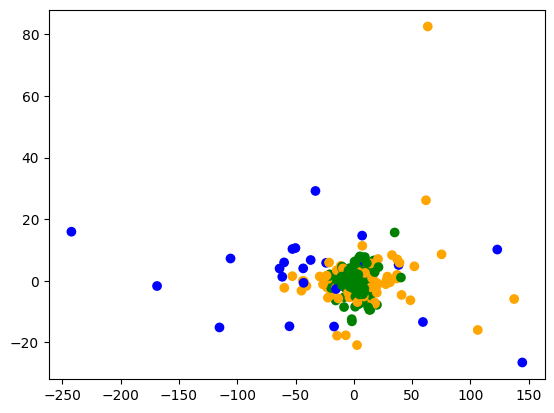

In [21]:
# 建立四个颜色的列表
colored = ['orange', 'green', 'blue', 'purple']
colr = [colored[i] for i in predict] #根据类别给每个样本赋予颜色
#去选择任意两个特征来看聚类的图，可以自行调整,第2个，第20个特征
plt.scatter(x[:, 1], x[:, 19], color=colr)

In [22]:
# 评判聚类效果：轮廓系数，聚类效果很难超过0.7，可以通过这个得分去调整kmeans和n_clusters
silhouette_score(x,predict)

0.5161198544883551

# 3.基于DBSCAN算法寻找异常值

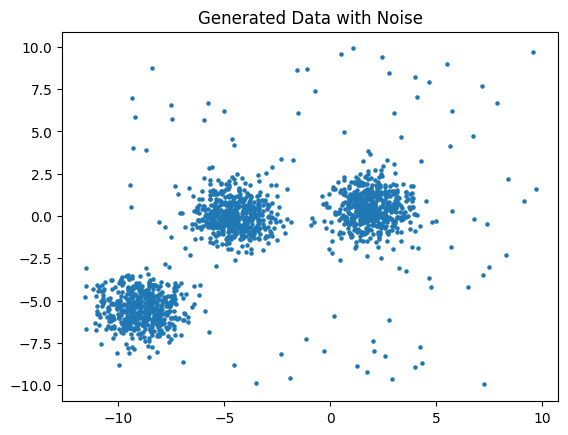

In [24]:
import random
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

# 生成样本数据
n_samples =1500
random_state = 170
X,y =make_blobs(n_samples = n_samples,random_state=random_state) # make_blobs是用于生成模拟数据集的一个函数

# 增加一些噪声点，往x中拼接噪声点
rng = np.random.RandomState(74)
X =np.concatenate([X,rng.uniform(low = -10,high = 10,size = (100,2))])

# 可视化数据
plt.scatter(X[:,0],X[:,1],s = 5)  # s是用来控制散点的大小的
plt.title('Generated Data with Noise')
plt.show()

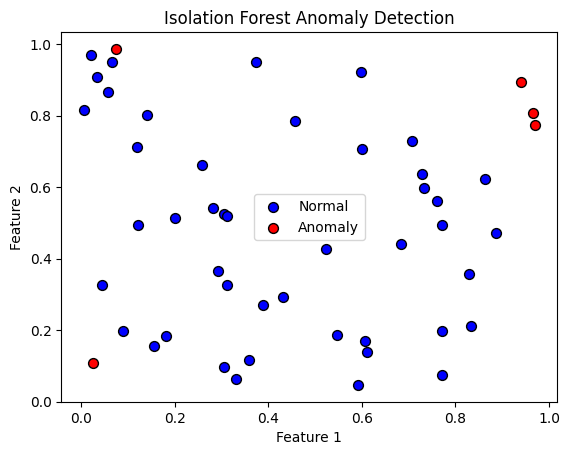

In [39]:
# 使用DBscan算法
# eps为半径，min_samples是最少包含几个点才能被认为是核心点
db = DBSCAN(eps = 0.5,min_samples=5).fit(X)
labels = db.labels_ # 得到每个点的分类
print(np.unique(labels))
# 设置标签为-1的点为噪声点
noise_mask = (labels == -1)
# 可视化聚类结果
plt.scatter(X[~noise_mask, 0], X[~noise_mask, 1], c=labels[~noise_mask], s=5, cmap='viridis') # 正常点用彩色标注
plt.scatter(X[noise_mask, 0], X[noise_mask, 1], c='red', s=5, label='Noise') # 噪声点用红色标注
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()

# 孤立森林

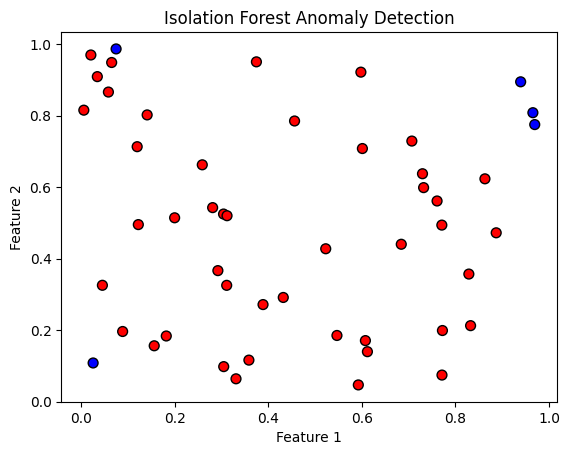

In [40]:
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# 随机生成50个数据点
np.random.seed(42)  # 为了结果的可重复性设置随机种子
X = np.random.rand(50, 2)  # 2维数据,2列好画图来解释

# 初始化Isolation Forest模型，contamination参数表示异常值比例，默认0.1
iso_forest = IsolationForest(random_state=42, contamination=0.1)

# 训练模型，随机建树的过程
iso_forest.fit(X)

# 预测每个点的异常分数，在树中的高度越低，越可能是异常点
scores = iso_forest.decision_function(X)

# print(scores)
# 将异常分数转换为1（正常）和-1（异常）的标签
labels = iso_forest.predict(X)
# print(labels)
# 绘制数据点和异常点
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap=plt.cm.bwr, edgecolor='k', s=50)
plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()